In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from mcp_boltzmann import annihilation as ann

In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [4]:
def vector_axial_couplings(T3, q):
    s2_theta_w = 0.22339 
    cv = T3 - 2*q*s2_theta_w
    ca = T3
    return cv, ca

In [5]:
MeV = 1
GeV = 1e3*MeV

m_mcp = 10*MeV
# m_mcp = 100.0*MeV
# m_mcp = 10*GeV

m_e = 0.511*MeV
m_mu = 105*MeV
m_tau = 1776*MeV
m_s = 95*MeV
m_c = 1270*MeV
m_b = 4180*MeV
m_t = 172.76*GeV
m_pi = 139.570 * MeV

Q = 1e-9 #mcp charge for plotting

q_u = 2/3
q_d = -1/3
q_s = -1/3
q_c = 2/3
q_t = 2/3
q_b = -1/3

T3_u = +1/2
T3_d = -1/2
T3_c = +1/2
T3_s = -1/2
T3_t = +1/2
T3_b = -1/2

T3_e = -1/2
T3_mu = -1/2
T3_tau = -1/2

cv_e, ca_e = vector_axial_couplings(T3_e, -1)
cv_mu, ca_mu = vector_axial_couplings(T3_mu, -1)
cv_tau, ca_tau = vector_axial_couplings(T3_tau, -1)

cv_u, ca_u = vector_axial_couplings(T3_u, q_u)
cv_d, ca_d = vector_axial_couplings(T3_d, q_d)
cv_c, ca_c = vector_axial_couplings(T3_c, q_c)
cv_s, ca_s = vector_axial_couplings(T3_s, q_s)
cv_t, ca_t = vector_axial_couplings(T3_t, q_t)
cv_b, ca_b = vector_axial_couplings(T3_b, q_b)

In [6]:
sigma_ee_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_e)
sigma_mumu_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_mu)
sigma_tautau_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_tau)

sigma_lq_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = 0.0) #pretend the charge of quarks is one so we can use this for ups and downs
sigma_ss_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_s, q_f=q_s)
sigma_cc_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_c, q_f=q_c)
sigma_bb_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_b, q_f=q_b)
sigma_tt_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_f = m_t, q_f=q_t)

sigma_pipi_ff = partial(ann.sigma_pipi_ff, m_mcp = m_mcp)

In [7]:
sigma_ee_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_e, q_f=-1, cv=cv_e, ca=ca_e)
sigma_mumu_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_mu, q_f=-1, cv=cv_mu, ca=ca_mu)
sigma_tautau_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_tau, q_f=-1, cv=cv_tau, ca=ca_tau)

sigma_uu_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = 0.0, q_f=q_u, cv=cv_u, ca=ca_u)
sigma_dd_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = 0.0, q_f=q_d, cv=cv_d, ca=ca_d)
sigma_ss_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_s, q_f=q_s, cv=cv_s, ca=ca_s)
sigma_cc_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_c, q_f=q_c, cv=cv_c, ca=ca_c)
sigma_bb_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_b, q_f=q_b, cv=cv_b, ca=ca_b)
sigma_tt_ff_Z = partial(ann.sigma_llff_Z_boson, m_mcp = m_mcp, m_f = m_t, q_f=q_t, cv=cv_t, ca=ca_t)

In [8]:
print(f'{(91.1880*1e3)**2:.3e}')

8.315e+09


In [9]:
# T_int = np.geomspace(1e-3, 1e6, 10000)
T_int = np.geomspace(1e-3, 1e6, 200)

Ix_table_e = np.array(
    [ann.Ix_fermi(sigma_ee_ff, m_mcp, m_e, T) for T in T_int]
)

Ix_table_e_MB = np.array(
    [ann.Ix(sigma_ee_ff, m_mcp, m_e, T) for T in T_int]
)

Ix_table_mu = np.array(
    [ann.Ix_fermi(sigma_mumu_ff, m_mcp, m_mu, T) for T in T_int]
)

Ix_table_tau = np.array(
    [ann.Ix_fermi(sigma_tautau_ff, m_mcp, m_tau, T) for T in T_int]
)

Ix_table_lq = np.array(
    [ann.Ix_fermi(sigma_lq_ff, m_mcp, 0.0, T) for T in T_int]
)

Ix_table_strange = np.array(
    [ann.Ix_fermi(sigma_ss_ff, m_mcp, m_s, T) for T in T_int]
)

Ix_table_charm = np.array(
    [ann.Ix_fermi(sigma_cc_ff, m_mcp, m_c, T) for T in T_int]
)

Ix_table_bot = np.array(
    [ann.Ix_fermi(sigma_bb_ff, m_mcp, m_b, T) for T in T_int]
)

Ix_table_top = np.array(
    [ann.Ix_fermi(sigma_tt_ff, m_mcp, m_t, T) for T in T_int]
)

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/annihilation.py:167: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(


In [10]:
Ix_table_pipi = np.array(
    [ann.Ix(sigma_pipi_ff, m_mcp, m_pi, T) for T in T_int]
)

### Tabulate rates incl Z boson contributions

In [11]:
T_int = np.geomspace(1e-3, 1e6, 200)

Ix_table_e_Z = np.array(
    [ann.Ix_fermi(sigma_ee_ff_Z, m_mcp, m_e, T) for T in T_int]
)

Ix_table_mu_Z = np.array(
    [ann.Ix_fermi(sigma_mumu_ff_Z, m_mcp, m_mu, T) for T in T_int]
)

Ix_table_tau_Z = np.array(
    [ann.Ix_fermi(sigma_tautau_ff_Z, m_mcp, m_tau, T) for T in T_int]
)

Ix_table_u_Z = np.array(
    [ann.Ix_fermi(sigma_uu_ff_Z, m_mcp, 0.0, T) for T in T_int]
)

Ix_table_d_Z = np.array(
    [ann.Ix_fermi(sigma_dd_ff_Z, m_mcp, 0.0, T) for T in T_int]
)

Ix_table_strange_Z = np.array(
    [ann.Ix_fermi(sigma_ss_ff_Z, m_mcp, m_s, T) for T in T_int]
)

Ix_table_charm_Z = np.array(
    [ann.Ix_fermi(sigma_cc_ff_Z, m_mcp, m_c, T) for T in T_int]
)

Ix_table_bot_Z = np.array(
    [ann.Ix_fermi(sigma_bb_ff_Z, m_mcp, m_b, T) for T in T_int]
)

Ix_table_top_Z = np.array(
    [ann.Ix_fermi(sigma_tt_ff_Z, m_mcp, m_t, T) for T in T_int]
)

### Plot quantum statistics correction

/var/folders/9z/c613c55s37gc7sthc_2397hc0000gn/T/ipykernel_81737/3977374969.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(T_int[1:], Ix_table_e[1:]/Ix_table_e_MB[1:])


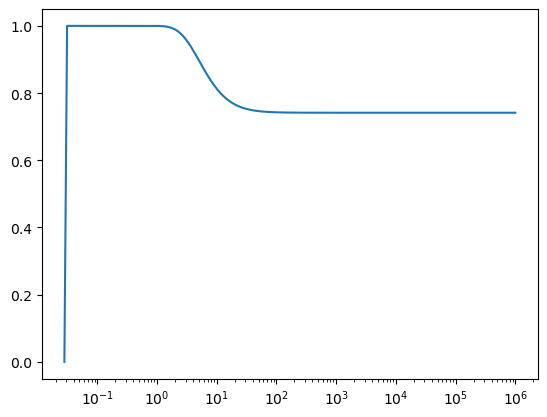

In [12]:
plt.plot(T_int[1:], Ix_table_e[1:]/Ix_table_e_MB[1:])
plt.xscale('log')

### Save rates to disk

In [13]:
LQCD = 200*MeV
rate_EM = Ix_table_e + Ix_table_mu + Ix_table_tau
rate_qcd = np.heaviside(T_int - LQCD, 0)*(Ix_table_lq + Ix_table_strange + Ix_table_charm + Ix_table_bot + Ix_table_top)
rate_had = np.heaviside(LQCD - T_int, 0)*Ix_table_pipi
rate_tot = rate_EM + rate_qcd

# np.savez_compressed(f'../output/rates/annihilation/ann_m_{m_mcp}_Q_1.npz',
#                    Temp_grid=T_int,
#                    rate=rate_tot
#                    )

### Interpolators for plots below

In [14]:
_Ix_table_e_I = interp1d(T_int, Ix_table_e, bounds_error=False, fill_value=(0, Ix_table_e[-1]))
_Ix_table_mu_I = interp1d(T_int, Ix_table_mu, bounds_error=False, fill_value=(0, Ix_table_mu[-1]))
_Ix_table_tau_I = interp1d(T_int, Ix_table_tau, bounds_error=False, fill_value=(0, Ix_table_tau[-1]))

_Ix_table_lq_I = interp1d(T_int, Ix_table_lq, bounds_error=False, fill_value=(0, Ix_table_lq[-1]))
_Ix_table_s_I = interp1d(T_int, Ix_table_strange, bounds_error=False, fill_value=(0, Ix_table_strange[-1]))
_Ix_table_c_I = interp1d(T_int, Ix_table_charm, bounds_error=False, fill_value=(0, Ix_table_charm[-1]))
_Ix_table_b_I = interp1d(T_int, Ix_table_bot, bounds_error=False, fill_value=(0, Ix_table_bot[-1]))
_Ix_table_t_I = interp1d(T_int, Ix_table_top, bounds_error=False, fill_value=(0, Ix_table_top[-1]))

_Ix_table_pi_I = interp1d(T_int, Ix_table_pipi, bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

In [15]:
_Ix_table_e_Z_I = interp1d(T_int, Ix_table_e_Z, bounds_error=False, fill_value=(0, Ix_table_e_Z[-1]))
_Ix_table_mu_Z_I = interp1d(T_int, Ix_table_mu_Z, bounds_error=False, fill_value=(0, Ix_table_mu_Z[-1]))
_Ix_table_tau_Z_I = interp1d(T_int, Ix_table_tau_Z, bounds_error=False, fill_value=(0, Ix_table_tau_Z[-1]))

_Ix_table_u_Z_I = interp1d(T_int, Ix_table_u_Z, bounds_error=False, fill_value=(0, Ix_table_u_Z[-1]))
_Ix_table_d_Z_I = interp1d(T_int, Ix_table_d_Z, bounds_error=False, fill_value=(0, Ix_table_d_Z[-1]))
_Ix_table_s_Z_I = interp1d(T_int, Ix_table_strange_Z, bounds_error=False, fill_value=(0, Ix_table_strange_Z[-1]))
_Ix_table_c_Z_I = interp1d(T_int, Ix_table_charm_Z, bounds_error=False, fill_value=(0, Ix_table_charm_Z[-1]))
_Ix_table_b_Z_I = interp1d(T_int, Ix_table_bot_Z, bounds_error=False, fill_value=(0, Ix_table_bot_Z[-1]))
_Ix_table_t_Z_I = interp1d(T_int, Ix_table_top_Z, bounds_error=False, fill_value=(0, Ix_table_top_Z[-1]))

### Forwards Collision terms

In [28]:
def C_f_ee(T, Q):
    return Q**2*_Ix_table_e_I(T)

def C_f_mumu(T, Q):
    return Q**2*_Ix_table_mu_I(T)

def C_f_tautau(T, Q):
    return Q**2*_Ix_table_tau_I(T)

def C_f_lq(T, Q):
    q_u = 2/3
    q_d = -1/3
    N_c = 3

    return N_c*Q**2*(q_u**2 + q_d**2)*_Ix_table_lq_I(T)

def C_f_ss(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_s_I(T) 

def C_f_cc(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_c_I(T) 

def C_f_bb(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_b_I(T) 

def C_f_tt(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_t_I(T) 

def C_f_pipi(T, Q):
    return Q**2*_Ix_table_pi_I(T)

In [29]:
def C_f_ee_Z(T, Q):
    return Q**2*_Ix_table_e_Z_I(T)

def C_f_mumu_Z(T, Q):
    return Q**2*_Ix_table_mu_Z_I(T)

def C_f_tautau_Z(T, Q):
    return Q**2*_Ix_table_tau_Z_I(T)

def C_f_uu_Z(T, Q):
    N_c = 3
    return N_c*Q**2*_Ix_table_u_Z_I(T)

def C_f_dd_Z(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_d_Z_I(T)

def C_f_ss_Z(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_s_Z_I(T) 

def C_f_cc_Z(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_c_Z_I(T) 

def C_f_bb_Z(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_b_Z_I(T) 

def C_f_tt_Z(T, Q):
    N_c = 3

    return N_c*Q**2*_Ix_table_t_Z_I(T) 

### Make Plots 

In [30]:
T_plot = np.geomspace(1e-3, 1e6, 1000)

In [31]:
shelton_f_ann = load_csv('../input/fig/2206.13530_fig7_left_annihilation.csv')
shelton_f_ann_fig8 = load_csv('../input/fig/2206.13530_fig8_left_annihilation.csv')

In [32]:
res_e = C_f_ee(T_plot, 1e-9)/T_plot**6
res_mu = C_f_mumu(T_plot, 1e-9)/T_plot**6
res_tau =  C_f_tautau(T_plot, 1e-9)/T_plot**6

res_lq = C_f_lq(T_plot, 1e-9)/T_plot**6
res_s = C_f_ss(T_plot, 1e-9)/T_plot**6
res_c = C_f_cc(T_plot, 1e-9)/T_plot**6
res_b = C_f_bb(T_plot, 1e-9)/T_plot**6
res_t = C_f_tt(T_plot, 1e-9)/T_plot**6

res_pi = np.heaviside(LQCD - T_plot , 0)*C_f_pipi(T_plot, 1e-9)/T_plot**6
res_em = res_e + res_mu
res_qcd = (res_lq + res_s + res_c + res_b + res_t)*np.heaviside(T_plot - LQCD, 0)

In [33]:
res_e_Z = C_f_ee_Z(T_plot, 1e-9)/T_plot**6
res_mu_Z = C_f_mumu_Z(T_plot, 1e-9)/T_plot**6
res_tau_Z =  C_f_tautau_Z(T_plot, 1e-9)/T_plot**6

res_u_Z = C_f_uu_Z(T_plot, 1e-9)/T_plot**6
res_d_Z = C_f_dd_Z(T_plot, 1e-9)/T_plot**6
res_s_Z = C_f_ss_Z(T_plot, 1e-9)/T_plot**6
res_c_Z = C_f_cc_Z(T_plot, 1e-9)/T_plot**6
res_b_Z = C_f_bb_Z(T_plot, 1e-9)/T_plot**6
res_t_Z = C_f_tt_Z(T_plot, 1e-9)/T_plot**6

res_em_Z = res_e_Z + res_mu_Z
res_qcd_Z = (res_u_Z + res_d_Z + res_s_Z + res_c_Z + res_b_Z + res_t_Z)*np.heaviside(T_plot - LQCD, 0)

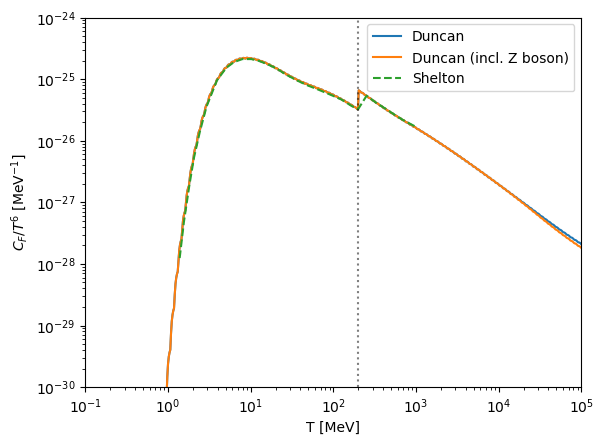

In [34]:
LQCD = 200*MeV
T_EW = 160*GeV


plt.plot(T_plot, (res_em + res_qcd), label='Duncan')
plt.plot(T_plot, 2*(res_em_Z + res_qcd_Z), label='Duncan (incl. Z boson)')
# plt.plot(T_plot, (res_em + res_qcd) + res_pi, label='Duncan (pions)')
# plt.plot(np.array(shelton_f_ann[0])*1e3, shelton_f_ann[1], label='Shelton', linestyle='dashed')
plt.plot(np.array(shelton_f_ann_fig8[0]), shelton_f_ann_fig8[1], label='Shelton', linestyle='dashed')
plt.yscale('log')
plt.xscale('log')

plt.xlabel('T [MeV]')
plt.ylabel(r'$C_{F}/T^6$ [MeV$^{-1}$]')

plt.axvline(LQCD, linestyle='dotted', color='black', alpha=0.5)
plt.axvline(T_EW, linestyle='dotted', color='black', alpha=0.5)


plt.ylim(1e-30, 1e-24)
plt.xlim(1e-1, 1e5)
# plt.xlim(1e3, 1e7)

plt.legend()

plt.show()